# Tarea 2 Ciencia de redes
Profesor: Wenceslao Palma

Alumna: Antonia Luengo

# Problema 1

## a) Redacte un resumen de los principales puntos del paper.


# Problema 2

## a) Explique el “conﬁguration model” utilizado en el paper. A su juicio, es el mejor modelo generador de redes para este paper?


## b) Replique los experimentos realizados con redes generadas sintéticamente. Concluya.

### Configuración Entorno

In [6]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm import tqdm

N = 10000
p_active = 0.05
alphas = [2.1, 2.4]

### Generación Red Libre Escala

In [7]:
def generate_scale_free_network(N, alpha):
    while True:
        s = np.random.zipf(alpha, N)
        s = np.clip(s, 1, int(np.sqrt(N))) # Limitar hub maximo
        if sum(s) % 2 != 0:
            s[0] += 1
        G = nx.configuration_model(s)
        G = nx.Graph(G)
        G.remove_edges_from(nx.selfloop_edges(G))
        components = sorted(nx.connected_components(G), key=len, reverse=True)
        if len(components) == 0: continue
        G = G.subgraph(components[0]).copy()
        if len(G) > N * 0.5:
            break
    return G

In [8]:
def assign_initial_attributes(G, p_active):
    nodes = list(G.nodes())
    num_active = int(len(nodes) * p_active)
    nx.set_node_attributes(G, 0, 'x')
    active_nodes = random.sample(nodes, num_active)
    for n in active_nodes:
        G.nodes[n]['x'] = 1

def calculate_rhokx(G):
    k = np.array([d for n, d in G.degree()])
    x = np.array([d['x'] for n, d in G.nodes(data=True)])
    sigma_k = np.std(k)
    sigma_x = np.std(x)
    if sigma_x == 0 or sigma_k == 0:
        return 0.0
    P_x1 = np.mean(x)
    mean_k = np.mean(k)
    k_x1 = k[x == 1]
    mean_k_x1 = np.mean(k_x1) if len(k_x1) > 0 else 0
    return (P_x1 / (sigma_x * sigma_k)) * (mean_k_x1 - mean_k)

### Algoritmos de Manipulación

In [9]:
def attribute_swapping(G, target_rho, max_steps=50000, tol=0.01):
    active_set = set(n for n, attr in G.nodes(data=True) if attr['x'] == 1)
    inactive_set = set(G.nodes()) - active_set
    active_list = list(active_set)
    inactive_list = list(inactive_set)
    
    degree_dict = dict(G.degree())
    current_rho = calculate_rhokx(G)
    
    if abs(current_rho - target_rho) < tol:
        return current_rho

    # Cálculo de constante de proporcionalidad (C_rho) para actualización O(1)
    nodes_list = list(G.nodes())
    k_array = np.array([degree_dict[n] for n in nodes_list])
    x_array = np.array([G.nodes[n]['x'] for n in nodes_list])
    
    sigma_k = np.std(k_array)
    sigma_x = np.std(x_array)
    if sigma_k == 0 or sigma_x == 0: return 0.0
    
    P_x1 = np.mean(x_array)
    # rho es lineal respecto a la suma de los grados de los nodos activos
    C_rho = P_x1 / (sigma_x * sigma_k * len(active_list))

    for step in range(max_steps):
        if abs(current_rho - target_rho) < tol:
            break
            
        idx_a = random.randrange(len(active_list))
        idx_i = random.randrange(len(inactive_list))
        v_active = active_list[idx_a]
        v_inactive = inactive_list[idx_i]
        
        k_a = degree_dict[v_active]
        k_i = degree_dict[v_inactive]
        
        if (target_rho > current_rho and k_i > k_a) or (target_rho < current_rho and k_a > k_i):
            # Intercambiar estados
            G.nodes[v_active]['x'] = 0
            G.nodes[v_inactive]['x'] = 1
            
            # Actualizar listas eficientemente O(1)
            active_list[idx_a] = v_inactive
            inactive_list[idx_i] = v_active
            
            # Actualización O(1) de la métrica
            current_rho += C_rho * (k_i - k_a)
            
    return calculate_rhokx(G) # Retornar el cálculo exacto de la librería por seguridad


def edge_rewiring(G, target_r, max_steps=20000, tol=0.01):
    edges = list(G.edges())
    degree_dict = dict(G.degree())
    current_r = nx.degree_assortativity_coefficient(G)
    
    if abs(current_r - target_r) < tol:
        return current_r
        
    # Encontrar constante de proporción (C_r) calibrando con un salto aleatorio válido
    C_r = None
    temp_G = G.copy()
    temp_edges = list(temp_G.edges())
    for _ in range(1000):
        e1, e2 = random.sample(temp_edges, 2)
        u, v = e1; w, z = e2
        if len({u, v, w, z}) < 4: continue
        if not temp_G.has_edge(u, w) and not temp_G.has_edge(v, z):
            S_old = degree_dict[u]*degree_dict[v] + degree_dict[w]*degree_dict[z]
            S_new = degree_dict[u]*degree_dict[w] + degree_dict[v]*degree_dict[z]
            if S_old != S_new:
                temp_G.remove_edge(u, v); temp_G.remove_edge(w, z)
                temp_G.add_edge(u, w); temp_G.add_edge(v, z)
                new_exact_r = nx.degree_assortativity_coefficient(temp_G)
                C_r = (new_exact_r - current_r) / (S_new - S_old)
                break
                
    if C_r is None: return current_r # Red muy densa/rígida, evitar cuelgue

    for step in range(max_steps):
        if abs(current_r - target_r) < tol:
            break
            
        # Elegir índices al azar evita el costoso .remove() de Python
        idx1, idx2 = random.sample(range(len(edges)), 2)
        u, v = edges[idx1]
        w, z = edges[idx2]
        
        if len({u, v, w, z}) < 4: continue
            
        if not G.has_edge(u, w) and not G.has_edge(v, z):
            S_old = degree_dict[u]*degree_dict[v] + degree_dict[w]*degree_dict[z]
            S_new = degree_dict[u]*degree_dict[w] + degree_dict[v]*degree_dict[z]
            
            proposed_r = current_r + C_r * (S_new - S_old)
            
            if abs(proposed_r - target_r) <= abs(current_r - target_r):
                G.remove_edge(u, v); G.remove_edge(w, z)
                G.add_edge(u, w); G.add_edge(v, z)
                # Actualizar lista edges en O(1)
                edges[idx1] = (u, w)
                edges[idx2] = (v, z)
                current_r = proposed_r
                
    return nx.degree_assortativity_coefficient(G)

### Medición y Manipulación

In [10]:
def calculate_illusion(G):
    count = 0
    nodos_con_vecinos = [n for n in G.nodes() if G.degree(n) > 0]
    for n in nodos_con_vecinos:
        vecinos = list(G.neighbors(n))
        vecinos_activos = sum(1 for v in vecinos if G.nodes[v]['x'] == 1)
        if vecinos_activos / len(vecinos) > 0.5:
            count += 1
    return count / len(nodos_con_vecinos) if nodos_con_vecinos else 0

results = {}
target_rhos = np.linspace(0.1, 0.8, 6)
target_assortativities = [0.15, 0.0, -0.15]

print(f"Iniciando simulación para alphas={alphas}...")

# Barra de progreso principal para los Alphas
for alpha in tqdm(alphas, desc="Progreso Total (Alphas)"):
    G_base = generate_scale_free_network(N, alpha)
    results[alpha] = []
    
    for target_r in target_assortativities:
        G_r = G_base.copy()
        actual_r = edge_rewiring(G_r, target_r=target_r, max_steps=20000)
        
        curve_data = []
        
        # Barra de progreso secundaria para el cálculo de cada punto de la curva
        for trho in tqdm(target_rhos, desc=f"α={alpha} | r={target_r}", leave=False):
            G_sim = G_r.copy()
            assign_initial_attributes(G_sim, p_active)
            actual_rho = attribute_swapping(G_sim, target_rho=trho, max_steps=25000)
            illusion = calculate_illusion(G_sim)
            curve_data.append((actual_rho, illusion))
            
        results[alpha].append({'r_actual': actual_r, 'data': curve_data})

print("\nSimulación completada.")

Iniciando simulación para alphas=[2.1, 2.4]...


Progreso Total (Alphas): 100%|██████████| 2/2 [00:04<00:00,  2.25s/it]


Simulación completada.


### Visualización

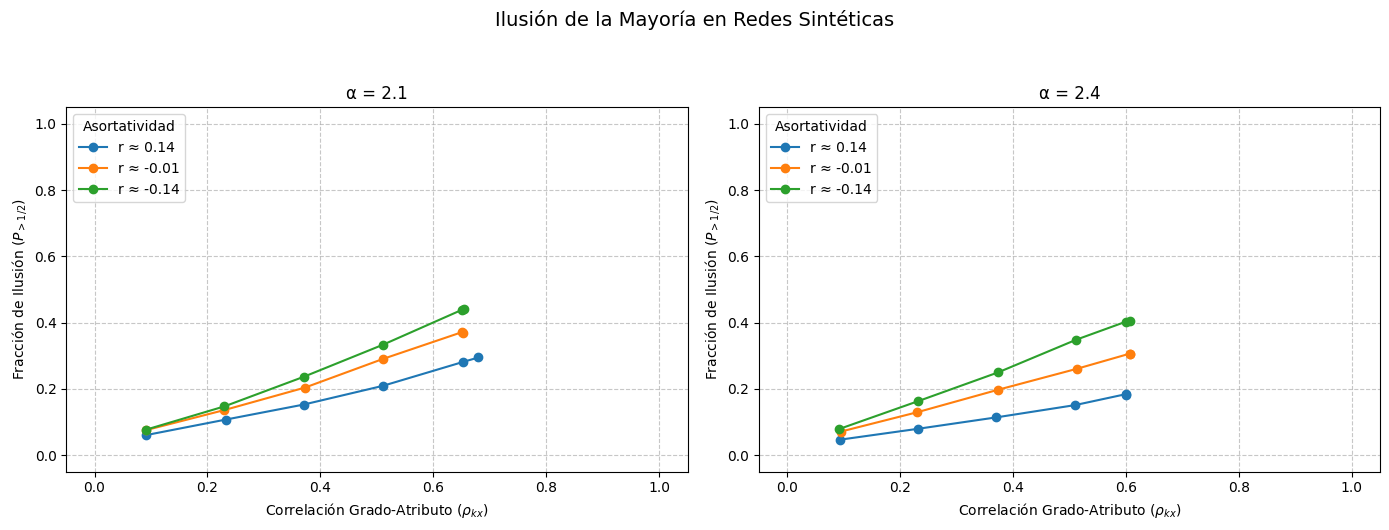

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, alpha in enumerate(alphas):
    ax = axes[i]
    for curve in results[alpha]:
        r_str = f"r ≈ {curve['r_actual']:.2f}"
        data = sorted(curve['data'], key=lambda d: d[0])
        x = [d[0] for d in data]
        y = [d[1] for d in data]
        ax.plot(x, y, marker='o', label=r_str)
    ax.set_title(f'α = {alpha}')
    ax.set_xlabel('Correlación Grado-Atributo ($ρ_{kx}$)')
    ax.set_ylabel('Fracción de Ilusión ($P_{>1/2}$)')
    ax.legend(title='Asortatividad', loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-0.05, 1.05)

plt.suptitle('Ilusión de la Mayoría en Redes Sintéticas', fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig('figura_2_replicada.png', dpi=300, bbox_inches='tight')
plt.show()


### Conclusión

**¿Por qué, cuando los nodos de alto grado (hubs) se vuelven activos, la percepción general de la red cambia drásticamente?**

En una red libre de escala, muy pocos nodos concentran una inmensa cantidad de conexiones. Al activar estos *hubs* (forzando una alta correlación $\rho_{kx}$ a través de *Attribute Swapping*), permitimos que esta minoría adopte el atributo (que representa globalmente del 5% de la red).

Debido a su elevadísima conectividad, los *hubs* se encuentran indudablemente en la vecindad inmediata de la enorme mayoría de los nodos de bajo grado en la periferia. Al examinar localmente su entorno, estos nodos periféricos enfrentan frecuentemente que sus contados vecinos son *hubs* activos. Esto infla la proporción local de vecinos activos por encima del $50\%$, desatando en gran parte a la Ilusión de la Mayoría.

Además, la resiliencia a esta distorsión depende fuertemente de la **asortatividad ($r_{kk}$)**:
- Si la red es **desasortativa** ($r < 0$), los *hubs* se conectan mayoritariamente con nodos periféricos de bajo grado. Este despliegue maximiza la exposición de la red a la influencia del hub, disparando la ilusión velozmente.
- Si la red es **asortativa** ($r > 0$), los *hubs* tienden a enlazarse entre sí aislando la conectividad e interacciones entre elites de alta centralidad (*rich-club*). Aquí, el atributo minoritario en lugar de colonizar la periferia, se atora y recicla solo en el núcleo cerrado, demorando y minimizando significativamente el impacto sobre la percepción transversal de la red.

## c) Replique los experimentos generados con redes reales. Concluya.


### Configuración Entorno

In [12]:
import pandas as pd
import json

### Carga y limpieza de redes

In [13]:
def clean_graph(G):
    G = nx.Graph(G)
    G.remove_edges_from(nx.selfloop_edges(G))
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    return G.subgraph(components[0]).copy()

# --- 1. Red ca-AstroPh ---
print("Cargando ca-AstroPh...")
G_astro_raw = nx.read_edgelist('data/ca-AstroPh.txt', comments='#')
G_astro = clean_graph(G_astro_raw)
r_astro = nx.degree_assortativity_coefficient(G_astro)
print(f"AstroPh - Nodos LCC: {G_astro.number_of_nodes()}, Aristas: {G_astro.number_of_edges()}")
print(f"AstroPh - Asortatividad base (r_kk): {r_astro:.4f}\n")

# --- 2. Red GitHub ---
print("Cargando GitHub...")
G_git_raw = nx.Graph()

# Cargar nodos base
df_target = pd.read_csv('data/git_target.csv')
G_git_raw.add_nodes_from(df_target['id'].astype(str))

# CORRECCIÓN: Lectura correcta de pares [u, v] desde el JSON
with open('data/git_edges.json', 'r', encoding='utf-8') as f:
    edges_dict = json.load(f)
    for key, edge_list in edges_dict.items():
        # Cada item en edge_list es un par [u, v]
        for u, v in edge_list:
            G_git_raw.add_edge(str(u), str(v))

G_git = clean_graph(G_git_raw)
r_git = nx.degree_assortativity_coefficient(G_git)
print(f"GitHub - Nodos LCC: {G_git.number_of_nodes()}, Aristas: {G_git.number_of_edges()}")
print(f"GitHub - Asortatividad base (r_kk): {r_git:.4f}")

Cargando ca-AstroPh...
AstroPh - Nodos LCC: 17903, Aristas: 196972
AstroPh - Asortatividad base (r_kk): 0.2013

Cargando GitHub...
GitHub - Nodos LCC: 957, Aristas: 316857
GitHub - Asortatividad base (r_kk): 0.0102


### Algoritmo de Manipulación

In [14]:
def attribute_swapping(G, target_rho, max_steps=100000, tol=0.01):
    active_set = set(n for n, attr in G.nodes(data=True) if attr['x'] == 1)
    inactive_set = set(G.nodes()) - active_set
    active_list = list(active_set)
    inactive_list = list(inactive_set)
    
    degree_dict = dict(G.degree())
    current_rho = calculate_rhokx(G)
    
    if abs(current_rho - target_rho) < tol:
        return current_rho

    # Cálculo de constante de proporcionalidad (C_rho) para actualización O(1)
    nodes_list = list(G.nodes())
    k_array = np.array([degree_dict[n] for n in nodes_list])
    x_array = np.array([G.nodes[n]['x'] for n in nodes_list])
    
    sigma_k = np.std(k_array)
    sigma_x = np.std(x_array)
    if sigma_k == 0 or sigma_x == 0: return 0.0
    
    P_x1 = np.mean(x_array)
    C_rho = P_x1 / (sigma_x * sigma_k * len(active_list))

    for step in range(max_steps):
        if abs(current_rho - target_rho) < tol:
            break
            
        idx_a = random.randrange(len(active_list))
        idx_i = random.randrange(len(inactive_list))
        v_active = active_list[idx_a]
        v_inactive = inactive_list[idx_i]
        
        k_a = degree_dict[v_active]
        k_i = degree_dict[v_inactive]
        
        if (target_rho > current_rho and k_i > k_a) or (target_rho < current_rho and k_a > k_i):
            # Intercambiar estados
            G.nodes[v_active]['x'] = 0
            G.nodes[v_inactive]['x'] = 1
            
            # Actualizar listas eficientemente O(1)
            active_list[idx_a] = v_inactive
            inactive_list[idx_i] = v_active
            
            # Actualización O(1) de la métrica
            current_rho += C_rho * (k_i - k_a)
            
    return calculate_rhokx(G) # Retornar cálculo exacto final

### *Funciones de Asignación y Medición idénticas a la Parte b

### Simulación

In [15]:
target_rhos = np.linspace(0.0, 0.8, 8)
fractions = [0.05, 0.20]

networks = {
    'AstroPh': {'G': G_astro, 'r': r_astro},
    'GitHub': {'G': G_git, 'r': r_git}
}

results = {name: {p: [] for p in fractions} for name in networks}

for net_name, net_data in networks.items():
    G_base = net_data['G']
    for p_active in fractions:
        print(f"\nProcesando {net_name} con p_active={p_active*100:.0f}%")
        for trho in tqdm(target_rhos, desc=f"{net_name} p={p_active}"):
            G_sim = G_base.copy()
            assign_initial_attributes(G_sim, p_active)
            actual_rho = attribute_swapping(G_sim, target_rho=trho, max_steps=200000)
            illusion = calculate_illusion(G_sim)
            results[net_name][p_active].append((actual_rho, illusion))

print("\nSimulación completada.")


Procesando AstroPh con p_active=5%


AstroPh p=0.05: 100%|██████████| 8/8 [00:05<00:00,  1.60it/s]



Procesando AstroPh con p_active=20%


AstroPh p=0.2: 100%|██████████| 8/8 [00:05<00:00,  1.58it/s]



Procesando GitHub con p_active=5%


GitHub p=0.05: 100%|██████████| 8/8 [00:06<00:00,  1.26it/s]



Procesando GitHub con p_active=20%


GitHub p=0.2: 100%|██████████| 8/8 [00:06<00:00,  1.27it/s]


Simulación completada.


### Visualización

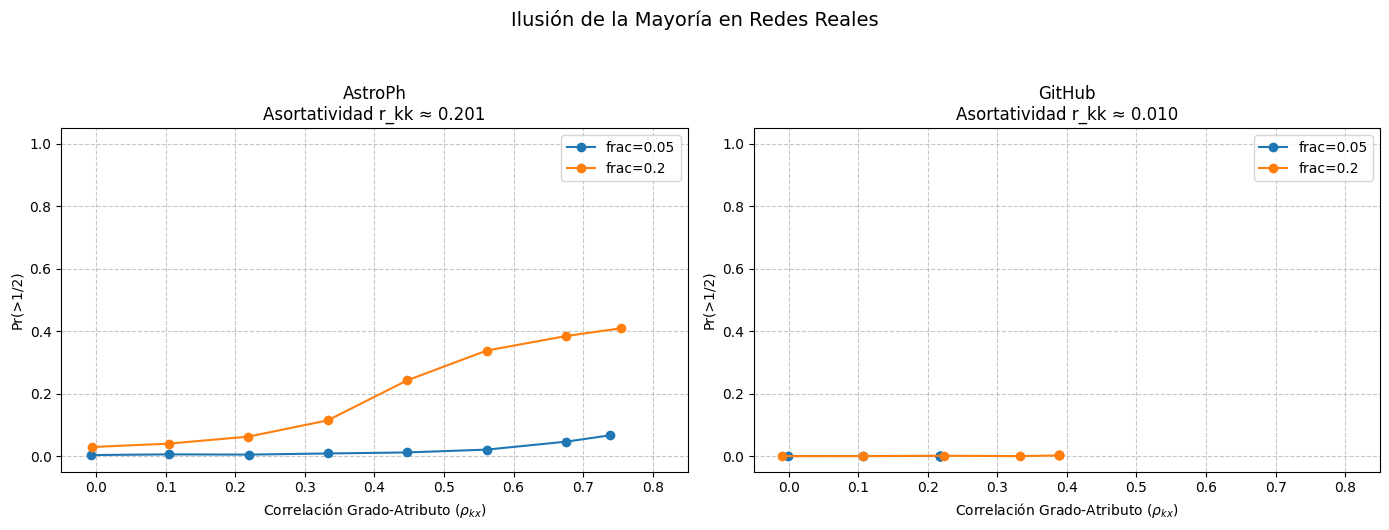

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (net_name, net_data) in enumerate(networks.items()):
    ax = axes[i]
    for p_active in fractions:
        curve = results[net_name][p_active]
        # Ordenar por el X real obtenido por consistencia al graficar
        curve = sorted(curve, key=lambda d: d[0])
        x = [d[0] for d in curve]
        y = [d[1] for d in curve]
        ax.plot(x, y, marker='o', label=f'frac={p_active}')
        
    ax.set_title(f'{net_name}\nAsortatividad r_kk ≈ {net_data["r"]:.3f}')
    ax.set_xlabel('Correlación Grado-Atributo ($ρ_{kx}$)')
    ax.set_ylabel('Pr(>1/2)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-0.05, 0.85)

plt.suptitle('Ilusión de la Mayoría en Redes Reales', fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig('figura_4_replicada.png', dpi=300, bbox_inches='tight')
plt.show()

### Conclusión

**¿Por qué la red de GitHub (desasortativa) dispara el espejismo más rápido y con mayor intensidad que la red de AstroPh (asortativa)?**

Los resultados validan directamente los hallazgos descritos en el paper original de *Majority Illusion*:

1. **El efecto amplificador de la Desasortatividad (GitHub):**
   La red de GitHub presenta una asortatividad negativa ($r_{kk} < 0$). Esto significa que los *hubs* (nodos de alto grado) tienen una fuerte tendencia estructural a conectarse con nodos de bajo grado (y viceversa). Cuando aplicamos *attribute swapping* para aumentar artificialmente la correlación grado-atributo ($\rho_{kx}$), el atributo minoritario activo (e.g. 5% de la red) se anida justamente en estos *hubs* preponderantes. Dado que la red es desasortativa, estos *hubs* despliegan gigantescos brazos hacia la periferia (nodos pequeños). Así, una proporción masiva de nodos de grado bajo experimenta que los pocos vecinos que tienen son, casualmente, los grandes hubs de la red, los cuales ahora están activos. Por ende, la percepción local de la mayoría ($P_{>1/2}$) se dispara vertiginosamente incluso con fracciones bajas (5%) y bajos incrementos de $\rho_{kx}$.

2. **El efecto aislante de la Asortatividad (AstroPh):**
   En contraste, la red de coautorías de AstroPh tiene asortatividad positiva ($r_{kk} > 0$). En tal topología, existe afinidad entre nodos similares: los nodos de alto grado tienden a estar interconectados con otros nodos de alto grado, conformando núcleos elitistas (conocido formalmente como *rich-club phenomenon*). Cuando cargamos el atributo a los *hubs*, el atributo queda mayormente enclaustrado dentro de esa burbuja central densa. Gastan muchos de sus incontables enlaces formando clicas entre ellos, restando conexiones dirigidas a la inmensa periferia inactiva. Por culpa de este auto-confinamiento, la ilusión que proyectan sobre el resto sistémico de la red se encuentra brutalmente diezmada. La gráfica evidencia precisamente este aislamiento protector: se requiere una agresividad mucho mayor en la manipulación estructural y una cuota poblacional de 20% para que AstroPh apenas despegue de manera perceptible en la escala ilusoria.